In [7]:
%matplotlib inline
# %matplotlib widget
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np

import method.datasets as ds
import method.preprocess.preprocess as ps
import method.core.pipeline as pipe
import method.models.rnn.rnn as model

from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results, plot_data_compare

import data_configs.custom_interp_data_config as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = ds.DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO     Preprocessor.transform start

INFO     Pipeline making step 'shifter'

INFO     Pipeline making step 'drop_intervals'

INFO     Pipeline making step 'filter'

INFO     Pipeline making step 'interpolation'

INFO     Pipeline making step 'smoother'

INFO     Pipeline making step 'scaler'

INFO     Pipeline making step 'feature_selector'

INFO     Pipeline making step 'splitter'

INFO     Preprocessor.transform end (0.25)s

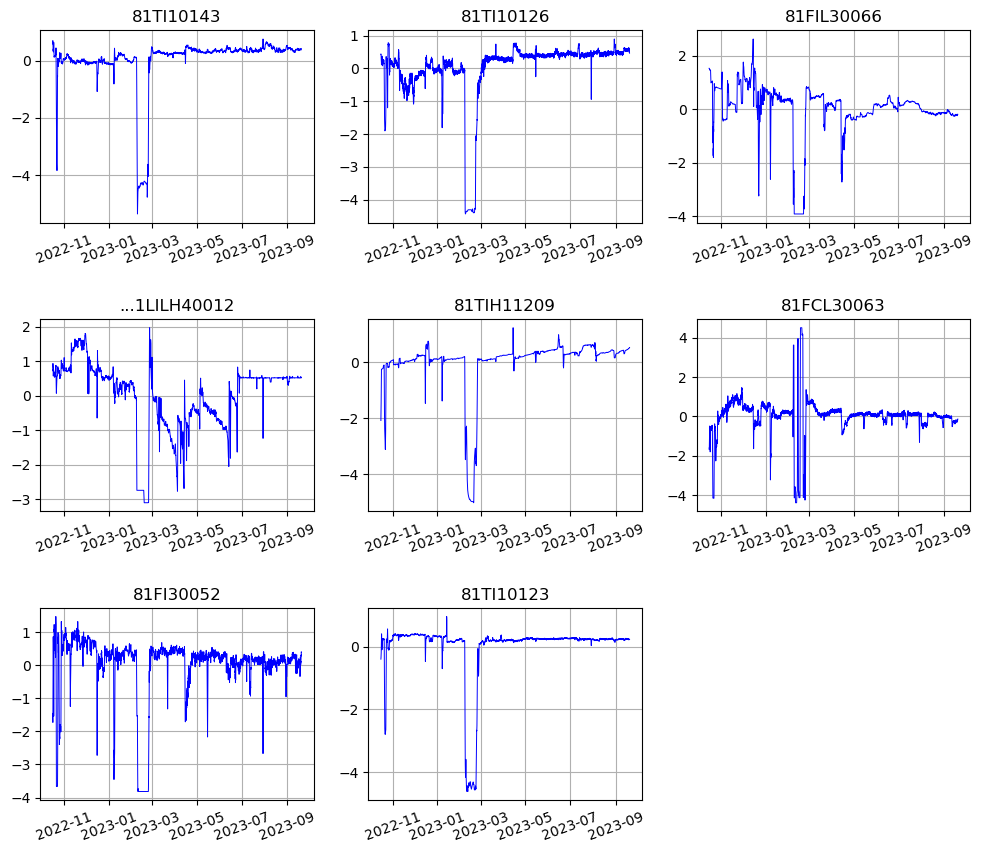

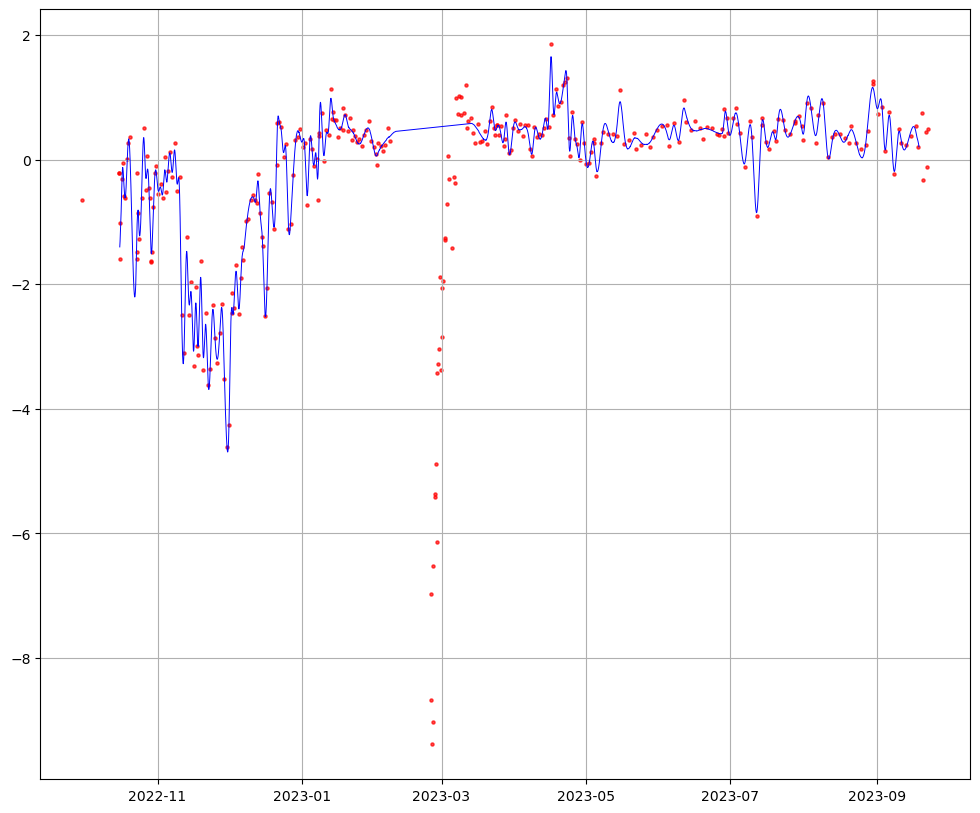

In [8]:
data_raw = ds.LoadDatasetStep(DATASET_CONFIG).fit_transform()


preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = ps.Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data_raw)

data_merged = data.merge_data()
ds_raw = data_raw.train.replace(new_y_scaler=data.train.y_scaler)
target_raw_scaled = ds_raw.scale(scale_y=True).y
target = data_merged.train.y
plot_data(data_merged.train.X.dropna(), plot_type="plot")
plot_data_compare(target_raw_scaled.dropna(), target.dropna())

INFO     RNN training model

INFO     Computing best lag using spearman correlation...

INFO     epoch 0: train: 0.5419, lr: 1.000e-02, valid: 0.0674, best_valid: 0.0674

INFO     epoch 10: train: 0.0872, lr: 1.000e-02, valid: 0.0666, best_valid: 0.0610

INFO     epoch 20: train: 0.0820, lr: 1.000e-02, valid: 0.0738, best_valid: 0.0610

...

INFO     epoch 40: train: 0.0824, lr: 1.000e-02, valid: 0.0831, best_valid: 0.0587

INFO     epoch 50: train: 0.0909, lr: 1.000e-02, valid: 0.0950, best_valid: 0.0587

INFO     epoch 60: train: 0.0922, lr: 1.000e-02, valid: 0.0711, best_valid: 0.0587

INFO     epoch 70: train: 0.0834, lr: 1.000e-02, valid: 0.3017, best_valid: 0.0587

INFO     RNN Model trained

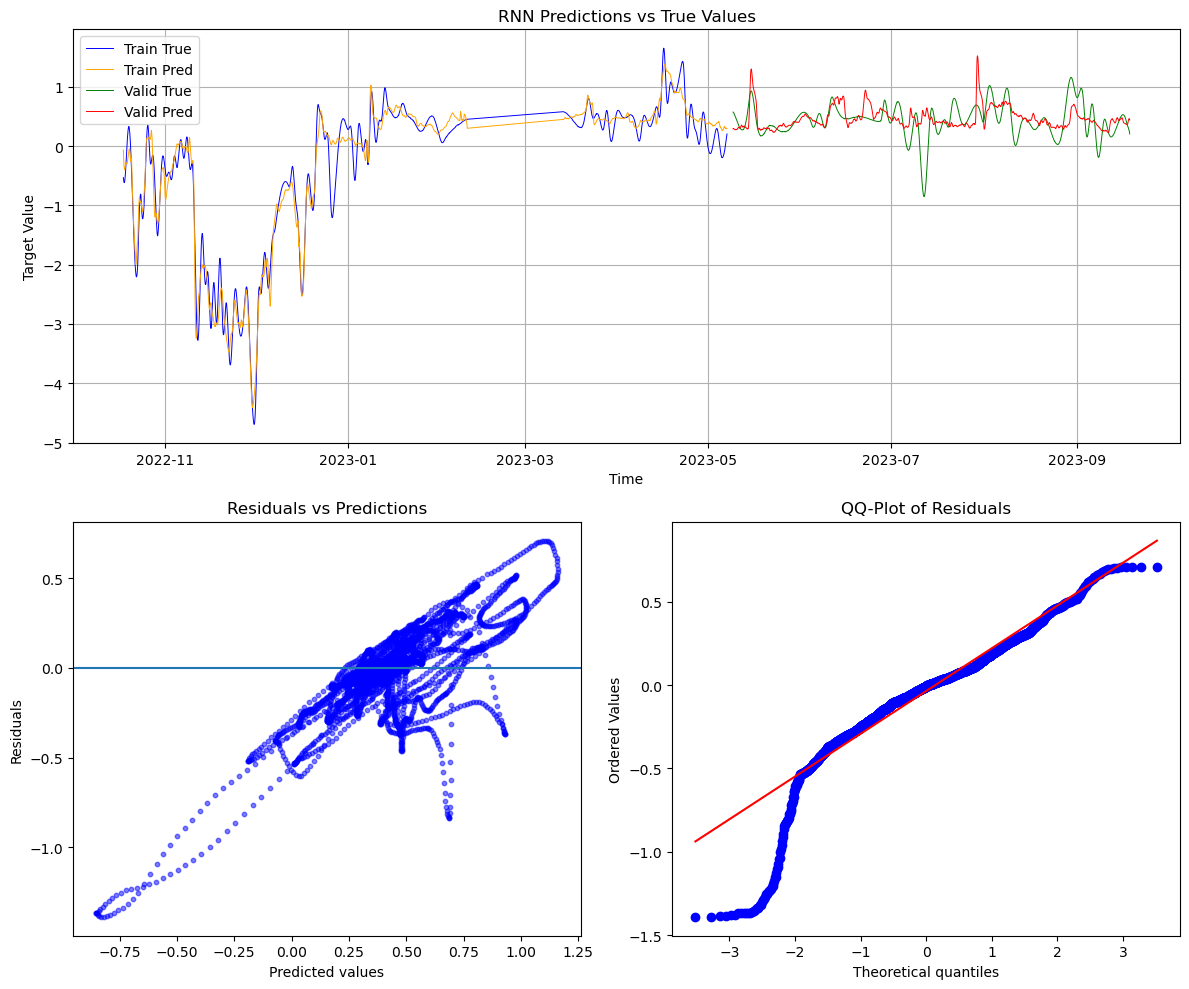

INFO     Metrics for Valid:

INFO                                                                                                               
         MAE                  0.185507                                                                             
         rMSE                 0.270093                                                                             
         MAPE                 1.386037                                                                             
         Pearson (p-value)    0.000000                                                                             
         Pearson              0.355739                                                                             
         R2                   0.018651                                                                             
         Hinge                0.107432                                                                             
         dtype: float64

In [9]:
torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

rnn_config = model.RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = model.RNN(rnn_config)

steps = [("rnn", rnn)] 
full_pipeline = pipe.Pipeline(steps)  # type: ignore
result = full_pipeline.fit_transform(data)

plot_results(result)

logger.debug("Metrics for Train:")
logger.debug("\n%s", metrics(**result["train"], cone=0.1))
logger.info("Metrics for Valid:")
logger.info("\n%s", metrics(**result["valid"], cone=0.1))